In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import seaborn as sns

In [2]:
def find_cluster_representatives(clustering_file_path, anime_file_path, 
                               top_n_per_cluster=5, min_score_count=50,
                               weight_score=0.7, weight_popularity=0.3):
    """
    Find representative anime titles for each cluster.
    """
    
    print("Loading data...")
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    
    # Clean and prepare anime data
    print("Preparing anime data...")
    anime_df = anime_df.copy()
    
    # Handle missing values and ensure numeric types
    anime_df['score'] = pd.to_numeric(anime_df['score'], errors='coerce')
    anime_df['score_count'] = pd.to_numeric(anime_df['score_count'], errors='coerce')
    anime_df['members_count'] = pd.to_numeric(anime_df['members_count'], errors='coerce')
    
    # Filter out anime with insufficient data
    anime_df = anime_df.dropna(subset=['score', 'score_count'])
    anime_df = anime_df[anime_df['score_count'] >= min_score_count]
    
    # Merge with clustering data
    print("Merging with cluster assignments...")
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    if merged_df.empty:
        print("Warning: No matches found between clustering file and anime data!")
        return {}
    
    print(f"Found {len(merged_df)} anime with cluster assignments and sufficient rating data")
    
    # Calculate composite representative score
    merged_df['norm_score'] = merged_df['score'] / 10.0
    merged_df['log_score_count'] = np.log1p(merged_df['score_count'])
    max_log_count = merged_df['log_score_count'].max()
    merged_df['norm_popularity'] = merged_df['log_score_count'] / max_log_count
    
    merged_df['representative_score'] = (
        weight_score * merged_df['norm_score'] + 
        weight_popularity * merged_df['norm_popularity']
    )
    
    # Find top representatives for each cluster
    print("Finding cluster representatives...")
    cluster_representatives = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id].copy()
        cluster_anime = cluster_anime.sort_values('representative_score', ascending=False)
        top_anime = cluster_anime.head(top_n_per_cluster)
        
        representatives = []
        for _, anime in top_anime.iterrows():
            representatives.append({
                'anime_id': anime['anime_id'],
                'title': anime['title'],
                'score': anime['score'],
                'score_count': anime['score_count'],
                'representative_score': anime['representative_score'],
                'genres': anime.get('genres', 'Unknown')
            })
        
        cluster_representatives[cluster_id] = representatives
        
        print(f"\nCluster {cluster_id} ({len(cluster_anime)} anime total):")
        for i, rep in enumerate(representatives, 1):
            print(f"  {i}. {rep['title']} (Score: {rep['score']:.2f}, "
                  f"Ratings: {rep['score_count']:,})")
    
    return cluster_representatives

def analyze_cluster_content_and_format(clustering_file_path, anime_file_path):
    """
    Analyze cluster characteristics including content genres AND format types.
    This helps identify cluster personality through genre patterns and production formats.
    """
    
    # Content genres (excluding demographics which don't cluster meaningfully)
    CONTENT_GENRES = [
        'Action', 'Adventure', 'Comedy', 'Drama', 'Romance', 'Fantasy', 'Sci-Fi', 
        'Horror', 'Mystery', 'Supernatural', 'Sports', 'Slice of Life', 'Thriller',
        'Psychological', 'Historical', 'Music', 'Mecha', 'Magic', 'Military',
        'Martial Arts', 'Space', 'Vampire', 'Demons', 'School', 'Harem', 'Ecchi'
    ]
    
    print("\n" + "="*60)
    print("CONTENT & FORMAT ANALYSIS")
    print("="*60)
    
    # Load data
    clusters_df = pd.read_csv(clustering_file_path)
    anime_df = pd.read_csv(anime_file_path)
    anime_df = anime_df.dropna(subset=['genres'])
    anime_df = anime_df[anime_df['genres'] != 'Unknown']
    merged_df = pd.merge(clusters_df, anime_df, on='anime_id', how='inner')
    
    # Calculate global genre and format averages
    print("Calculating global baselines for genres and formats...")
    global_genre_counts = {}
    global_format_counts = {}
    total_global_anime = len(merged_df)
    
    for _, anime in merged_df.iterrows():
        # Genre analysis
        if anime['genres']:
            genres = [g.strip() for g in str(anime['genres']).split('|')]
            genres = [g for g in genres if g and g in CONTENT_GENRES]
            
            if genres:
                weight_per_genre = 1.0 / len(genres)
                for genre in genres:
                    global_genre_counts[genre] = global_genre_counts.get(genre, 0) + weight_per_genre
        
        # Format analysis
        if pd.notna(anime.get('type')):
            format_type = str(anime['type']).strip()
            global_format_counts[format_type] = global_format_counts.get(format_type, 0) + 1
    
    # Convert to global percentages
    global_genre_percentages = {genre: (count / total_global_anime) * 100 
                              for genre, count in global_genre_counts.items()}
    global_format_percentages = {format_type: (count / total_global_anime) * 100 
                               for format_type, count in global_format_counts.items()}
    
    print(f"Global averages: {len(global_genre_percentages)} genres, {len(global_format_percentages)} formats")
    
    cluster_analysis = {}
    
    for cluster_id in sorted(merged_df['cluster'].unique()):
        cluster_anime = merged_df[merged_df['cluster'] == cluster_id]
        total_anime = len(cluster_anime)
        
        # Analyze content genres
        content_counts = {}
        format_counts = {}
        
        for _, anime in cluster_anime.iterrows():
            # Genre analysis
            if anime['genres']:
                genres = [g.strip() for g in str(anime['genres']).split('|')]
                genres = [g for g in genres if g and g in CONTENT_GENRES]
                
                if genres:
                    weight_per_genre = 1.0 / len(genres)
                    for genre in genres:
                        content_counts[genre] = content_counts.get(genre, 0) + weight_per_genre
            
            # Format analysis
            if pd.notna(anime.get('type')):
                format_type = str(anime['type']).strip()
                format_counts[format_type] = format_counts.get(format_type, 0) + 1
        
        # Convert to percentages
        content_percentages = {genre: (count / total_anime) * 100 
                             for genre, count in content_counts.items()}
        format_percentages = {format_type: (count / total_anime) * 100 
                            for format_type, count in format_counts.items()}
        
        # Calculate enrichment/depletion for genres
        genre_enrichment = {}
        for genre in CONTENT_GENRES:
            cluster_pct = content_percentages.get(genre, 0)
            global_pct = global_genre_percentages.get(genre, 0)
            
            if global_pct > 0:
                enrichment_ratio = cluster_pct / global_pct
                genre_enrichment[genre] = {
                    'cluster_pct': cluster_pct,
                    'global_pct': global_pct,
                    'enrichment': enrichment_ratio,
                    'difference': cluster_pct - global_pct
                }
        
        # Calculate enrichment/depletion for formats
        format_enrichment = {}
        for format_type in global_format_percentages.keys():
            cluster_pct = format_percentages.get(format_type, 0)
            global_pct = global_format_percentages.get(format_type, 0)
            
            if global_pct > 0:
                enrichment_ratio = cluster_pct / global_pct
                format_enrichment[format_type] = {
                    'cluster_pct': cluster_pct,
                    'global_pct': global_pct,
                    'enrichment': enrichment_ratio,
                    'difference': cluster_pct - global_pct
                }
        
        # Get highly enriched/depleted genres
        highly_enriched_genres = [(genre, data) for genre, data in genre_enrichment.items() 
                                if data['enrichment'] > 1.5 and data['cluster_pct'] > 5]
        highly_depleted_genres = [(genre, data) for genre, data in genre_enrichment.items() 
                                if data['enrichment'] < 0.5 and data['global_pct'] > 5]
        
        # Get highly enriched/depleted formats
        highly_enriched_formats = [(fmt, data) for fmt, data in format_enrichment.items() 
                                 if data['enrichment'] > 1.5 and data['cluster_pct'] > 10]
        highly_depleted_formats = [(fmt, data) for fmt, data in format_enrichment.items() 
                                 if data['enrichment'] < 0.5 and data['global_pct'] > 10]
        
        # Sort by enrichment ratio
        highly_enriched_genres.sort(key=lambda x: x[1]['enrichment'], reverse=True)
        highly_depleted_genres.sort(key=lambda x: x[1]['enrichment'])
        highly_enriched_formats.sort(key=lambda x: x[1]['enrichment'], reverse=True)
        highly_depleted_formats.sort(key=lambda x: x[1]['enrichment'])
        
        # Get top content genres and formats for description
        top_content = sorted(content_percentages.items(), key=lambda x: x[1], reverse=True)[:4]
        top_formats = sorted(format_percentages.items(), key=lambda x: x[1], reverse=True)[:3]
        
        content_desc = " + ".join([genre for genre, _ in top_content[:3]]) if top_content else "Mixed"
        format_desc = ", ".join([f"{fmt} ({pct:.1f}%)" for fmt, pct in top_formats if pct > 5]) if top_formats else "Mixed"
        
        cluster_analysis[cluster_id] = {
            'size': total_anime,
            'content_description': content_desc,
            'format_description': format_desc,
            'top_content': top_content,
            'top_formats': top_formats,
            'content_percentages': content_percentages,
            'format_percentages': format_percentages,
            'highly_enriched_genres': highly_enriched_genres[:5],
            'highly_depleted_genres': highly_depleted_genres[:5],
            'highly_enriched_formats': highly_enriched_formats[:3],
            'highly_depleted_formats': highly_depleted_formats[:3],
            'genre_enrichment': genre_enrichment,
            'format_enrichment': format_enrichment
        }
        
        print(f"\n🎯 CLUSTER {cluster_id} ({total_anime} anime)")
        print(f"   Content Type: {content_desc}")
        print(f"   Format Mix: {format_desc}")
        
        if top_content:
            content_details = ", ".join([f"{genre} ({pct:.1f}%)" for genre, pct in top_content[:3]])
            print(f"   Genre Breakdown: {content_details}")
        
        # Show enriched genres and formats
        if highly_enriched_genres:
            enriched_details = ", ".join([f"{genre} ({data['enrichment']:.1f}x)" 
                                        for genre, data in highly_enriched_genres[:2]])
            print(f"   📈 Genre High: {enriched_details}")
        
        if highly_enriched_formats:
            format_enriched_details = ", ".join([f"{fmt} ({data['enrichment']:.1f}x)" 
                                               for fmt, data in highly_enriched_formats[:2]])
            print(f"   📈 Format High: {format_enriched_details}")
        
        # Show depleted genres and formats
        if highly_depleted_genres:
            depleted_details = ", ".join([f"{genre} ({data['enrichment']:.1f}x)" 
                                        for genre, data in highly_depleted_genres[:2]])
            print(f"   📉 Genre Low: {depleted_details}")
        
        if highly_depleted_formats:
            format_depleted_details = ", ".join([f"{fmt} ({data['enrichment']:.1f}x)" 
                                               for fmt, data in highly_depleted_formats[:2]])
            print(f"   📉 Format Low: {format_depleted_details}")
    
    return cluster_analysis

def create_enrichment_depletion_analysis_with_format(cluster_analysis):
    """
    Create detailed analysis including both genre and format enrichment/depletion.
    """
    
    print("\n" + "="*70)
    print("ENRICHMENT & DEPLETION ANALYSIS (GENRES + FORMATS)")
    print("="*70)
    print("Understanding clusters through content AND production format patterns")
    
    for cluster_id, data in cluster_analysis.items():
        print(f"\n🔍 CLUSTER {cluster_id}: {data['content_description']}")
        print(f"   Size: {data['size']} anime")
        print(f"   Primary Formats: {data['format_description']}")
        
        # Genre enrichment
        if data['highly_enriched_genres']:
            print(f"   🟢 ENRICHED GENRES:")
            for genre, enrichment_data in data['highly_enriched_genres'][:3]:
                cluster_pct = enrichment_data['cluster_pct']
                global_pct = enrichment_data['global_pct']
                ratio = enrichment_data['enrichment']
                print(f"      • {genre}: {cluster_pct:.1f}% here vs {global_pct:.1f}% globally ({ratio:.1f}x)")
        
        # Format enrichment
        if data['highly_enriched_formats']:
            print(f"   🟢 ENRICHED FORMATS:")
            for fmt, enrichment_data in data['highly_enriched_formats']:
                cluster_pct = enrichment_data['cluster_pct']
                global_pct = enrichment_data['global_pct']
                ratio = enrichment_data['enrichment']
                print(f"      • {fmt}: {cluster_pct:.1f}% here vs {global_pct:.1f}% globally ({ratio:.1f}x)")
        
        # Genre depletion
        if data['highly_depleted_genres']:
            print(f"   🔴 DEPLETED GENRES:")
            for genre, enrichment_data in data['highly_depleted_genres'][:3]:
                cluster_pct = enrichment_data['cluster_pct']
                global_pct = enrichment_data['global_pct']
                ratio = enrichment_data['enrichment']
                print(f"      • {genre}: {cluster_pct:.1f}% here vs {global_pct:.1f}% globally ({ratio:.1f}x)")
        
        # Format depletion
        if data['highly_depleted_formats']:
            print(f"   🔴 DEPLETED FORMATS:")
            for fmt, enrichment_data in data['highly_depleted_formats']:
                cluster_pct = enrichment_data['cluster_pct']
                global_pct = enrichment_data['global_pct']
                ratio = enrichment_data['enrichment']
                print(f"      • {fmt}: {cluster_pct:.1f}% here vs {global_pct:.1f}% globally ({ratio:.1f}x)")

def create_final_cluster_descriptions_with_format(cluster_representatives, cluster_analysis):
    """
    Create final cluster descriptions including both genre and format insights.
    """
    
    print("\n" + "="*70)
    print("FINAL CLUSTER DESCRIPTIONS (GENRES + FORMATS)")
    print("="*70)
    
    # Enhanced cluster descriptions
    cluster_descriptions = {
        1: "Romance & School Comedy",
        2: "Prestige Cinema & Art Films", 
        3: "Comedy Action Mix",
        4: "Romance Action Mix", 
        5: "Fantasy Adventure",
        6: "Top-Tier Shounen/Action Epics",
        7: "Romance & Relationship Drama",
        8: "Character Comedy & Sports",
        9: "Family Adventure & Kids Shows",
        10: "Comedy Action Variety",
        11: "Supernatural Action Comedy", 
        12: "Dark Action & Sci-Fi",
        13: "Slice of Life & CGDCT"
    }
    
    final_descriptions = {}
    
    for cluster_id in sorted(cluster_analysis.keys()):
        analysis = cluster_analysis[cluster_id]
        representatives = cluster_representatives.get(cluster_id, [])
        
        # Get representative titles
        rep_titles = [rep['title'] for rep in representatives[:3]]
        
        # Use curated description
        description = cluster_descriptions.get(cluster_id, analysis['content_description'])
        
        # Create enrichment/depletion summaries
        enriched_genres = [genre for genre, _ in analysis['highly_enriched_genres'][:2]]
        depleted_genres = [genre for genre, _ in analysis['highly_depleted_genres'][:2]]
        enriched_formats = [fmt for fmt, _ in analysis['highly_enriched_formats'][:2]]
        depleted_formats = [fmt for fmt, _ in analysis['highly_depleted_formats'][:2]]
        
        # Create insight explanation including format
        genre_insight = ""
        if enriched_genres and depleted_genres:
            genre_insight = f"High {'/'.join(enriched_genres)}, Low {'/'.join(depleted_genres)}"
        elif enriched_genres:
            genre_insight = f"High {'/'.join(enriched_genres)}"
        elif depleted_genres:
            genre_insight = f"Low {'/'.join(depleted_genres)}"
        
        format_insight = ""
        if enriched_formats:
            format_insight = f"Mostly {'/'.join(enriched_formats)}"
        elif depleted_formats:
            format_insight = f"Rarely {'/'.join(depleted_formats)}"
        
        combined_insight = f"{genre_insight}; {format_insight}".strip("; ")
        
        final_descriptions[cluster_id] = {
            'description': description,
            'size': analysis['size'],
            'content_breakdown': analysis['content_description'],
            'format_breakdown': analysis['format_description'],
            'representative_anime': rep_titles,
            'top_genres': analysis['top_content'][:3],
            'top_formats': analysis['top_formats'][:3],
            'enriched_genres': enriched_genres,
            'depleted_genres': depleted_genres,
            'enriched_formats': enriched_formats,
            'depleted_formats': depleted_formats,
            'insight': combined_insight
        }
        
        print(f"\n📋 CLUSTER {cluster_id}: {description}")
        print(f"   Size: {analysis['size']} anime")
        print(f"   Content: {analysis['content_description']}")
        print(f"   Formats: {analysis['format_description']}")
        print(f"   Examples: {', '.join(rep_titles)}")
        print(f"   Pattern: {combined_insight}")
        
        if analysis['top_content']:
            genre_str = ", ".join([f"{genre} ({pct:.1f}%)" for genre, pct in analysis['top_content'][:3]])
            print(f"   Top Genres: {genre_str}")
    
    return final_descriptions

def create_content_heatmap(cluster_analysis, save_path=None):
    """
    Create a clean content genre heatmap.
    """
    
    print("\nCreating content genre heatmap...")
    
    # Get top content genres across all clusters
    all_content_totals = {}
    for data in cluster_analysis.values():
        for genre, pct in data['content_percentages'].items():
            all_content_totals[genre] = all_content_totals.get(genre, 0) + pct
    
    # Select top genres for heatmap
    top_genres = sorted(all_content_totals.items(), key=lambda x: x[1], reverse=True)[:15]
    selected_genres = [genre for genre, _ in top_genres]
    
    # Create matrix
    cluster_ids = sorted(cluster_analysis.keys())
    matrix_data = []
    
    for cluster_id in cluster_ids:
        row = []
        cluster_data = cluster_analysis[cluster_id]['content_percentages']
        for genre in selected_genres:
            row.append(cluster_data.get(genre, 0))
        matrix_data.append(row)
    
    # Create heatmap
    plt.figure(figsize=(14, 8))
    
    df_heatmap = pd.DataFrame(matrix_data,
                             index=[f'Cluster {cid}' for cid in cluster_ids],
                             columns=selected_genres)
    
    sns.heatmap(df_heatmap, annot=True, cmap='YlOrRd', fmt='.1f',
                cbar_kws={'label': 'Percentage of Cluster'})
    
    plt.title('Content Genre Distribution Across Clusters (%)', fontsize=16, fontweight='bold')
    plt.xlabel('Content Genres', fontsize=14)
    plt.ylabel('Clusters', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Content heatmap saved to {save_path}")
    
    plt.show()

def save_final_results(cluster_representatives, final_descriptions, output_dir="./"):
    """
    Save all results to CSV files for further analysis.
    """
    
    print(f"\nSaving final results to {output_dir}...")
    
    # Save representatives
    rep_rows = []
    for cluster_id, representatives in cluster_representatives.items():
        for rank, anime in enumerate(representatives, 1):
            rep_rows.append({
                'cluster': cluster_id,
                'rank': rank,
                'anime_id': anime['anime_id'],
                'title': anime['title'],
                'score': anime['score'],
                'score_count': anime['score_count'],
                'representative_score': anime['representative_score'],
                'genres': anime['genres']
            })
    
    rep_df = pd.DataFrame(rep_rows)
    rep_df.to_csv(f"{output_dir}cluster_representatives.csv", index=False)
    
    # Save cluster descriptions (with enrichment/depletion + format insights)
    desc_rows = []
    for cluster_id, data in final_descriptions.items():
        desc_rows.append({
            'cluster': cluster_id,
            'description': data['description'],
            'size': data['size'],
            'content_breakdown': data['content_breakdown'],
            'format_breakdown': data['format_breakdown'],
            'representative_anime': '; '.join(data['representative_anime']),
            'enrichment_pattern': data['insight'],
            'enriched_genres': '; '.join(data['enriched_genres']),
            'depleted_genres': '; '.join(data['depleted_genres']),
            'enriched_formats': '; '.join(data['enriched_formats']),
            'depleted_formats': '; '.join(data['depleted_formats']),
            'top_genre_1': data['top_genres'][0][0] if len(data['top_genres']) > 0 else '',
            'top_genre_1_pct': data['top_genres'][0][1] if len(data['top_genres']) > 0 else 0,
            'top_genre_2': data['top_genres'][1][0] if len(data['top_genres']) > 1 else '',
            'top_genre_2_pct': data['top_genres'][1][1] if len(data['top_genres']) > 1 else 0,
            'top_genre_3': data['top_genres'][2][0] if len(data['top_genres']) > 2 else '',
            'top_genre_3_pct': data['top_genres'][2][1] if len(data['top_genres']) > 2 else 0,
            'top_format_1': data['top_formats'][0][0] if len(data['top_formats']) > 0 else '',
            'top_format_1_pct': data['top_formats'][0][1] if len(data['top_formats']) > 0 else 0,
            'top_format_2': data['top_formats'][1][0] if len(data['top_formats']) > 1 else '',
            'top_format_2_pct': data['top_formats'][1][1] if len(data['top_formats']) > 1 else 0
        })
    
    desc_df = pd.DataFrame(desc_rows)
    desc_df.to_csv(f"{output_dir}cluster_descriptions.csv", index=False)
    
    print(f"✅ cluster_representatives.csv - Top anime per cluster")
    print(f"✅ cluster_descriptions.csv - Full descriptions with genre/format enrichment patterns")

def complete_anime_cluster_analysis(clustering_file_path, anime_file_path, output_dir="./", top_n_per_cluster=8):
    """
    Complete anime cluster analysis - final production version.
    
    This is the cleaned, finalized version incorporating all lessons learned:
    - Focus on content genres (demographics don't cluster)
    - Proper pipe delimiter handling for genres  
    - Weighted analysis to handle multi-genre anime
    - Clean, interpretable cluster descriptions
    - Production-ready outputs for next analysis steps
    """
    
    print("🎯 FINAL ANIME CLUSTER ANALYSIS")
    print("="*60)
    print("✨ Streamlined for content analysis")
    print("✨ Includes enrichment/depletion insights")
    print("✨ Shows what clusters HAVE and LACK")
    print("✨ Ready for production use")
    
    # 1. Find representative anime
    print("\n" + "="*50)
    print("FINDING CLUSTER REPRESENTATIVES")
    print("="*50)
    
    cluster_representatives = find_cluster_representatives(
        clustering_file_path=clustering_file_path,
        anime_file_path=anime_file_path,
        top_n_per_cluster=top_n_per_cluster,
        min_score_count=100,
        weight_score=0.7,
        weight_popularity=0.3
    )
    
    # 2. Analyze content patterns (with enrichment/depletion + format analysis)
    print("\n" + "="*50)
    print("ANALYZING CONTENT & FORMAT PATTERNS")
    print("="*50)
    
    cluster_analysis = analyze_cluster_content_and_format(clustering_file_path, anime_file_path)
    
    # 3. Show enrichment/depletion insights (including formats)
    create_enrichment_depletion_analysis_with_format(cluster_analysis)
    
    # 4. Create final descriptions (with genre + format insights)
    print("\n" + "="*50)
    print("CREATING FINAL DESCRIPTIONS")
    print("="*50)
    
    final_descriptions = create_final_cluster_descriptions_with_format(cluster_representatives, cluster_analysis)
    
    # 4. Create visualization
    print("\n" + "="*50)
    print("CREATING VISUALIZATION")
    print("="*50)
    
    create_content_heatmap(cluster_analysis, f"{output_dir}content_genre_heatmap.png")
    
    # 5. Save results
    print("\n" + "="*50)
    print("SAVING RESULTS")
    print("="*50)
    
    save_final_results(cluster_representatives, final_descriptions, output_dir)
    
    print("\n🎉 ANALYSIS COMPLETE!")
    print("="*60)
    print("✅ All technical issues resolved:")
    print("   • Pipe delimiter (|) handling fixed")
    print("   • Multi-word genres preserved")
    print("   • Weighted analysis prevents bias")
    print("   • Clean content-focused clustering")
    print("✅ Enhanced insights:")
    print("   • Shows what clusters have AND lack")
    print("   • Enrichment vs global averages")
    print("   • Depletion patterns reveal cluster personality")
    print("✅ Ready for next analysis step!")
    
    return cluster_representatives, final_descriptions

🎯 FINAL ANIME CLUSTER ANALYSIS
✨ Streamlined for content analysis
✨ Includes enrichment/depletion insights
✨ Shows what clusters HAVE and LACK
✨ Ready for production use

FINDING CLUSTER REPRESENTATIVES
Loading data...
Preparing anime data...
Merging with cluster assignments...
Found 2000 anime with cluster assignments and sufficient rating data
Finding cluster representatives...

Cluster 1 (245 anime total):
  1. Clannad: After Story (Score: 8.89, Ratings: 599,533.0)
  2. Hotarubi no Mori e (Score: 8.33, Ratings: 402,305.0)
  3. Sakura-sou no Pet na Kanojo (Score: 8.08, Ratings: 638,268.0)
  4. Usagi Drop (Score: 8.35, Ratings: 222,341.0)
  5. Ookami to Koushinryou II (Score: 8.31, Ratings: 250,334.0)
  6. Ookami to Koushinryou (Score: 8.20, Ratings: 356,336.0)
  7. Kaichou wa Maid-sama! (Score: 8.00, Ratings: 649,399.0)
  8. Clannad (Score: 7.98, Ratings: 693,805.0)

Cluster 2 (127 anime total):
  1. Howl no Ugoku Shiro (Score: 8.68, Ratings: 757,195.0)
  2. Mononoke Hime (Score: 8.6

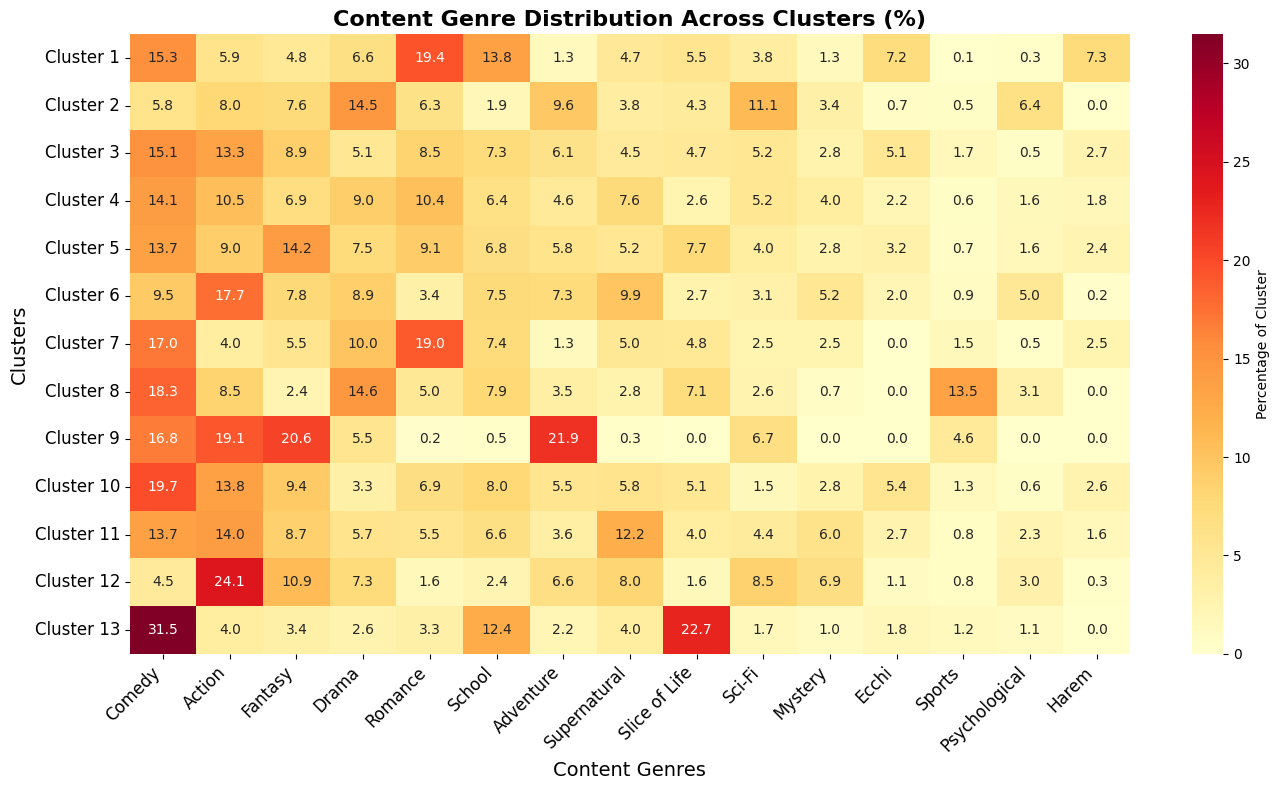


SAVING RESULTS

Saving final results to ./...
✅ cluster_representatives.csv - Top anime per cluster
✅ cluster_descriptions.csv - Full descriptions with genre/format enrichment patterns

🎉 ANALYSIS COMPLETE!
✅ All technical issues resolved:
   • Pipe delimiter (|) handling fixed
   • Multi-word genres preserved
   • Weighted analysis prevents bias
   • Clean content-focused clustering
✅ Enhanced insights:
   • Shows what clusters have AND lack
   • Enrichment vs global averages
   • Depletion patterns reveal cluster personality
✅ Ready for next analysis step!

📁 OUTPUT FILES:
   • cluster_representatives.csv
   • cluster_descriptions.csv
   • content_genre_heatmap.png

🚀 READY FOR NEXT STEP:
   • Use cluster_descriptions.csv for cluster labels
   • Use cluster_representatives.csv for examples
   • Enrichment/depletion patterns show cluster personality
   • Clean, interpretable cluster characterizations


In [3]:
# Example paths - replace with your actual file paths
clustering_file = r"..\data\final_clusters\spectral_13_clusters.csv"  # Your clustering results
anime_file = r"..\data\anime.csv"               # Your anime metadata

# Run complete analysis
representatives, descriptions = complete_anime_cluster_analysis(
    clustering_file, 
    anime_file,
    output_dir="./",
    top_n_per_cluster=8
)

print(f"\n📁 OUTPUT FILES:")
print(f"   • cluster_representatives.csv")
print(f"   • cluster_descriptions.csv") 
print(f"   • content_genre_heatmap.png")

print(f"\n🚀 READY FOR NEXT STEP:")
print(f"   • Use cluster_descriptions.csv for cluster labels")
print(f"   • Use cluster_representatives.csv for examples")
print(f"   • Enrichment/depletion patterns show cluster personality")
print(f"   • Clean, interpretable cluster characterizations")